In [1]:
# Code from Katharina to set up MPI
import os

# Use conda's newer libstdc++ instead of the system one
conda_lib = os.path.expanduser("~/.conda/envs/hnn-core-env/lib")
ld_path = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{conda_lib}:{ld_path}"

# UCX settings (from before)
os.environ["UCX_TLS"] = "tcp,self,sm"
os.environ["UCX_NET_DEVICES"] = "all"


# MPI paths
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
mpi_lib = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/lib"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"
if mpi_lib not in ld_path:
    os.environ["LD_LIBRARY_PATH"] = f"{mpi_lib}:{os.environ['LD_LIBRARY_PATH']}"

import sys
# Add MPI bin directory to PATH
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"

# print("Updated PATH to include MPI")
# print("MPI location:", mpi_bin)

import os
print("PATH:", os.environ.get('PATH', 'NOT SET'))
print("Which mpiexec:")
import subprocess
result = subprocess.run(['which', 'mpiexec'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "mpiexec not found")

PATH: /oscar/rt/sw/external/hpcx-mpi/2.25.1/bin:/oscar/home/xgao35/venvs/hnn-core-calcium-202602/bin:/oscar/rt/9.6/25/x86_64_v3/code-server-4.96.4-2mbqypo7726gva5cbeogfppy2doijdhq/lib/vscode/bin/remote-cli:/users/xgao35/.pixi/bin:/users/xgao35/.conda/envs/hnn_core/bin:/oscar/runtime/bin:/oscar/rt/9.6/25/spack/x86_64_v3/code-server-4.96.4-2mbqypo7726gva5cbeogfppy2doijdhq/bin:/users/xgao35/.pixi/bin:/users/xgao35/miniconda3/bin:/users/xgao35/miniconda3/condabin:/users/xgao35/.conda/envs/hnn_core/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/lpp/mmfs/bin:/usr/lpp/mmfs/sbin:/users/xgao35/bin:/users/xgao35/bin
Which mpiexec:
/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin/mpiexec



In [2]:
import sys
import hnn_core
import os.path as op
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import numpy as np
import json

from hnn_core import duecker_ET_model, read_params, simulate_dipole, average_dipoles, read_dipole, Dipole
from hnn_core.viz import plot_dipole
from copy import deepcopy
from hnn_core import MPIBackend, hnn_io

--No graphics will be displayed.


In [3]:
# Load 80AMT single subject data 
df = pd.read_csv('/users/xgao35/Desktop/HNN_NGFC/Data/BETA09_sp80AMT_5mmROI_dipole.txt', sep = ' ')

x = df.iloc[:, 0].to_numpy()
y = df.iloc[:, 1].to_numpy() * 1e9 # Scaling the experimental dipole to the right unit
dpl_data = Dipole(x, y)

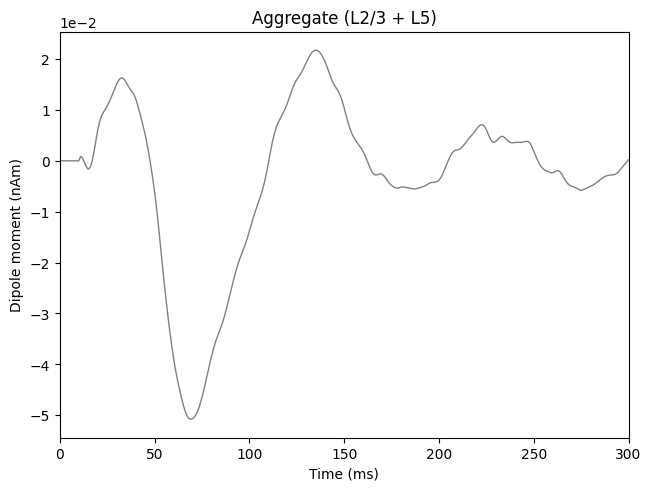

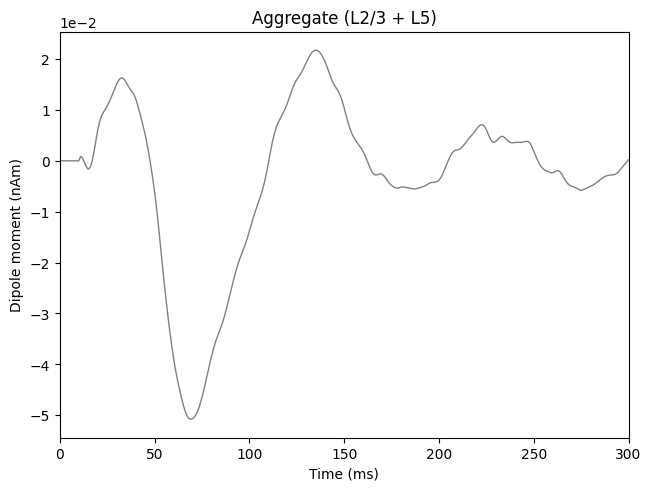

In [4]:
# Plot the experimental dipole for sanity check
plot_dipole(dpl_data)

In [5]:
# Load SEP siimulation 
with open('Networks/duecker_ET_supra_ERP.json') as f:
    p = json.load(f)

In [56]:
net = duecker_ET_model()

In [57]:
def add_L2_inhibitory_drives(net, weight_gabaa=0.0004, weight_gabab=0.0004):
    net.add_connection(src_gids='ngfc', target_gids="L2_inhibitory", loc='soma', receptor='gabaa', weight=weight_gabaa, delay=0.1, lamtha=6.125)
    net.add_connection(src_gids='ngfc', target_gids="L2_inhibitory", loc='soma', receptor='gabab', weight=weight_gabab, delay=0.1, lamtha=6.125)

In [58]:
# Add NGF drive 
ngfc_weights_gabab = (
    {"L2_pyramidal": 0.9 * 5, 
    "L5_pyramidal": 0.9 * 5}
)
ngfc_weights_gabaa = (
    {"L2_pyramidal": 0.04, 
    "L5_pyramidal": 0.04}
)

net.add_ngfc_drive(
    "ngfc",
    mu=10.0,
    sigma=10.0,
    numspikes=2,
    weights_gabab=ngfc_weights_gabab,
    weights_gabaa=ngfc_weights_gabaa,
    synapse_type="both",
    synaptic_delays={"L2_pyramidal": 0.1, "L5_pyramidal": 0.1},
)

# This is a very scrappy way to add the NGFC -> L2 interneuron connection
# Better implementation should include this in add_ngfc_drive, but this will suffice for now
add_L2_inhibitory_drives(net)

In [59]:
# Add the proximal and distal drives, hand tune the drive parameters here

# Proximal 1 
# (zeroing out the connections between this drive and inhibitory neurons, as we want this drive to approximate immediate somatic activation from axonal backpropagation)
evprox1_global_scale = 0.4
net.add_evoked_drive(
    f'evprox_1',
    mu=2, sigma=1, numspikes=2,
    weights_ampa={'L2_pyramidal': p['external_drives']['prox1']['weights_ampa']['L2_pyramidal'] * evprox1_global_scale,
                  'L2_inhibitory':p['external_drives']['prox1']['weights_ampa']['L2_inhibitory']* evprox1_global_scale * 0,
                  'L5_pyramidal': p['external_drives']['prox1']['weights_ampa']['L5_pyramidal'] * evprox1_global_scale,
                  'L5_inhibitory':p['external_drives']['prox1']['weights_ampa']['L5_inhibitory']* evprox1_global_scale * 0},
    weights_nmda={'L2_pyramidal': p['external_drives']['prox1']['weights_nmda']['L2_pyramidal'] * evprox1_global_scale,
                  'L2_inhibitory':p['external_drives']['prox1']['weights_nmda']['L2_inhibitory'] * evprox1_global_scale * 0,
                  'L5_pyramidal': p['external_drives']['prox1']['weights_nmda']['L5_pyramidal'] * evprox1_global_scale,
                  'L5_inhibitory':p['external_drives']['prox1']['weights_nmda']['L5_inhibitory'] * evprox1_global_scale * 0},
    location='proximal',
    synaptic_delays={'L2_pyramidal': 0.0, 'L2_inhibitory': 0.0, 'L5_pyramidal': 0.0, 'L5_inhibitory': 0.0}, # All set to zero for immediate activation
    event_seed=p['external_drives']['prox1']['event_seed']
)

# Distal 1
evdist1_global_scale = 3
net.add_evoked_drive(f'evdist_1',
                mu=0,
                sigma=1.0040786,
                numspikes=3,
                location='distal',
                weights_ampa={'L2_inhibitory': 0.00015856138634223074 * evdist1_global_scale,
                             'L2_pyramidal': 0.0002 * evdist1_global_scale * 100,
                             'L5_pyramidal': 0.025 * 0.5 * evdist1_global_scale}, 
                weights_nmda={'L2_inhibitory': 0.009312719515251288 * evdist1_global_scale * 0.8,
                             'L2_pyramidal': 0.0002 * evdist1_global_scale * 100,
                             'L5_pyramidal': 0.03 * 0.5 * evdist1_global_scale},
                synaptic_delays={'L2_inhibitory': 0.0, 'L2_pyramidal': 0.0, 'L5_pyramidal': 0.0}, # All set to zero for immediate activation
                event_seed=p['external_drives']['dist1']['event_seed']
)

# Distal 2
dist2_global_scale = 1
net.add_evoked_drive(
    'evdist_2',
    mu=55, sigma=5, numspikes=2,
    weights_ampa={'L2_pyramidal': p['external_drives']['dist1']['weights_ampa']['L2_pyramidal'] * dist2_global_scale * 10,
                  'L2_inhibitory':p['external_drives']['dist1']['weights_ampa']['L2_inhibitory'] * dist2_global_scale * 1e4,
                  'L5_pyramidal': p['external_drives']['dist1']['weights_ampa']['L5_pyramidal'] * dist2_global_scale},
    weights_nmda={'L2_pyramidal': p['external_drives']['dist1']['weights_nmda']['L2_pyramidal'] * dist2_global_scale * 10,
                  'L2_inhibitory':p['external_drives']['dist1']['weights_nmda']['L2_inhibitory'] * dist2_global_scale * 1e3,
                  'L5_pyramidal': p['external_drives']['dist1']['weights_nmda']['L5_pyramidal'] * dist2_global_scale * 10},
    location='distal',
    synaptic_delays={'L2_pyramidal': 0.1, 'L2_inhibitory': 0.1, 'L5_pyramidal': 0.1},
    event_seed=p['external_drives']['dist1']['event_seed'],
)

# Proximal 2
evprox2_global_scale = 0.1
net.add_evoked_drive(
    'evprox_2',
    mu=140, sigma=7, numspikes=1,
    weights_ampa={'L2_pyramidal': p['external_drives']['prox2']['weights_ampa']['L2_pyramidal'] * evprox2_global_scale,
                  'L2_inhibitory':p['external_drives']['prox2']['weights_ampa']['L2_inhibitory']* evprox2_global_scale,
                  'L5_pyramidal': p['external_drives']['prox2']['weights_ampa']['L5_pyramidal'] * evprox2_global_scale,
                  'L5_inhibitory':p['external_drives']['prox2']['weights_ampa']['L5_inhibitory']* evprox2_global_scale},
    weights_nmda={'L2_pyramidal': p['external_drives']['prox2']['weights_nmda']['L2_pyramidal'] * evprox2_global_scale,
                  'L2_inhibitory':p['external_drives']['prox2']['weights_nmda']['L2_inhibitory'] * evprox2_global_scale,
                  'L5_pyramidal': p['external_drives']['prox2']['weights_nmda']['L5_pyramidal'] * evprox2_global_scale,
                  'L5_inhibitory':p['external_drives']['prox2']['weights_nmda']['L5_inhibitory'] * evprox2_global_scale},
    location='proximal',
    synaptic_delays={'L2_pyramidal': 0.1, 'L2_inhibitory': 0.1, 'L5_pyramidal': 1.0, 'L5_inhibitory': 1.0},
    event_seed=p['external_drives']['prox2']['event_seed'],
)

# Distal 3
dist3_global_scale = 0.1
net.add_evoked_drive(
    'evdist_3',
    mu=170, sigma=7, numspikes=1,
    weights_ampa={'L2_pyramidal': p['external_drives']['dist1']['weights_ampa']['L2_pyramidal'] * dist3_global_scale,
                  'L2_inhibitory':p['external_drives']['dist1']['weights_ampa']['L2_inhibitory'] * dist3_global_scale,
                  'L5_pyramidal': p['external_drives']['dist1']['weights_ampa']['L5_pyramidal'] * dist3_global_scale},
    weights_nmda={'L2_pyramidal': p['external_drives']['dist1']['weights_nmda']['L2_pyramidal'] * dist3_global_scale,
                  'L2_inhibitory':p['external_drives']['dist1']['weights_nmda']['L2_inhibitory'] * dist3_global_scale,
                  'L5_pyramidal': p['external_drives']['dist1']['weights_nmda']['L5_pyramidal'] * dist3_global_scale},
    location='distal',
    synaptic_delays={'L2_pyramidal': 0.1, 'L2_inhibitory': 0.1, 'L5_pyramidal': 0.1},
    event_seed=p['external_drives']['dist1']['event_seed'],
)

# Proximal 3
evprox3_global_scale = 0.1
net.add_evoked_drive(
    'evprox_3',
    mu=220, sigma=10, numspikes=1,
    weights_ampa={'L2_pyramidal': p['external_drives']['prox2']['weights_ampa']['L2_pyramidal'] * evprox3_global_scale,
                  'L2_inhibitory':p['external_drives']['prox2']['weights_ampa']['L2_inhibitory']* evprox3_global_scale,
                  'L5_pyramidal': p['external_drives']['prox2']['weights_ampa']['L5_pyramidal'] * evprox3_global_scale,
                  'L5_inhibitory':p['external_drives']['prox2']['weights_ampa']['L5_inhibitory']* evprox3_global_scale},
    weights_nmda={'L2_pyramidal': p['external_drives']['prox2']['weights_nmda']['L2_pyramidal'] * evprox3_global_scale,
                  'L2_inhibitory':p['external_drives']['prox2']['weights_nmda']['L2_inhibitory'] * evprox3_global_scale,
                  'L5_pyramidal': p['external_drives']['prox2']['weights_nmda']['L5_pyramidal'] * evprox3_global_scale,
                  'L5_inhibitory':p['external_drives']['prox2']['weights_nmda']['L5_inhibitory'] * evprox3_global_scale},
    location='proximal',
    synaptic_delays={'L2_pyramidal': 0.1, 'L2_inhibitory': 0.1, 'L5_pyramidal': 1.0, 'L5_inhibitory': 1.0},
    event_seed=p['external_drives']['prox2']['event_seed'],
)

In [60]:
tstop=300
with MPIBackend(n_procs=6, mpi_cmd='mpiexec'):
    dpls = simulate_dipole(net, tstop=tstop, dt=0.025, n_trials=3, bsl_cor='duecker')

MPI will run 3 trial(s) sequentially by distributing network neurons over 6 processes.
numprocs=6
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110

In [61]:
# Smooth and scale the dipole
dpls_smoothed = [dpl.smooth(20).scale(0.8) for dpl in dpls]

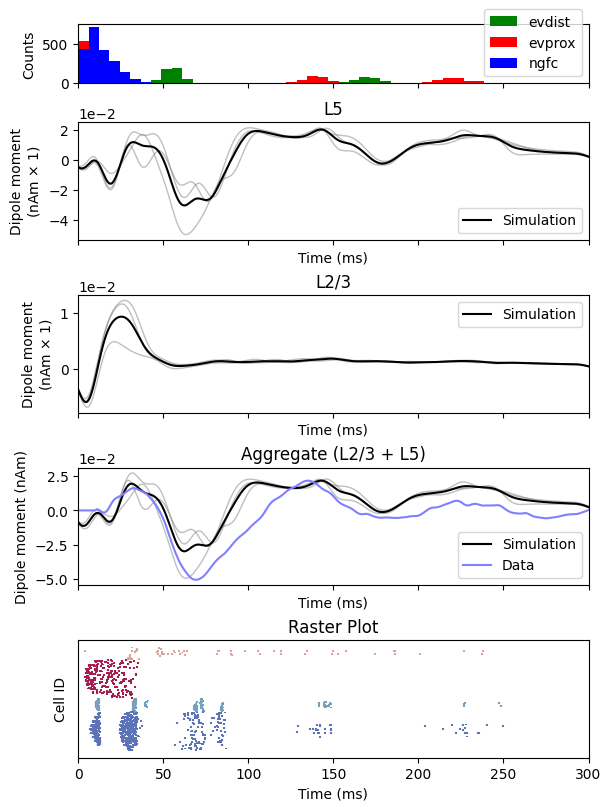

In [64]:
from hnn_core.viz import plot_spikes_raster

fig, axes = plt.subplots(5, 1, figsize=(6, 8), constrained_layout=True, height_ratios=[1,2,2,2,2],sharex=True)

net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['evprox','evdist','ngfc'], trial_idx=0, show=False)

plot_dipole(dpls_smoothed.copy(), ax = axes[1], layer='L5', show=False, average=True,label='Simulation')
plot_dipole(dpls_smoothed.copy(), ax = axes[2], layer='L2', show=False, average=True,label='Simulation')
plot_dipole(dpls_smoothed.copy(), ax = axes[3], layer='agg', show=False, average=True,label='Simulation')
plot_dipole(dpl_data, ax = axes[3], color='b', show=False)
axes[3].lines[-1].set_label('Data')
axes[3].lines[-1].set_linewidth(1.5)
axes[3].legend()

net.cell_response.plot_spikes_raster(ax=axes[4],show=False, show_legend=False)

plt.show()


In [66]:
# Export the hand-tuned dipole parameters
hnn_io.write_network_configuration(net,output='Networks/BETA4_80_hand.json')